# COS711 Assignment 1: MLP on Protein Tertiary Structure

Predict the **RMSD** (Å) of a candidate protein fold from physicochemical descriptors, then study
(1) how MLP design choices affect training, and (2) whether **learning-rate warmup** makes a network
more **robust to magnitude pruning**.

**Layout:** this notebook tells the story. The mechanics live in short modules under `src/`
(one concept per file). Written justifications are in `docs/`.

| Section | Contents |
|---|---|
| 1 | Data preparation: first look, splitting, feature relevance, outliers, scaling, imbalance |
| 2 | The MLP, training loop and baseline (incl. re-checking the feature and loss-weighting decisions) |
| 3 | Core investigation: optimisers, architecture, activation functions *(to come)* |
| 4 | Research investigation: warmup vs pruning *(to come)* |

**How to run:** from the repo root, `python3 -m venv .venv && source .venv/bin/activate &&
pip install -r requirements.txt`, then open this notebook and *Restart & Run All*.

In [1]:
import sys
from pathlib import Path

# Make `src` importable whether the notebook is started from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (FEATURES, INPUT_FEATURES, TARGET, RMSD_BIN_EDGES, RMSD_BIN_LABELS,
                      load_raw, clean, rmsd_bin, split_train_test, stratified_kfold)
from src.preprocessing import Preprocessor, LOG_FEATURES
from src.evaluation import regression_metrics, per_bin_metrics
from src import plotting
from src.plotting import BLUE, ORANGE, TEXT_PRIMARY, TEXT_SECONDARY

plotting.apply_style()
pd.set_option("display.precision", 3)

## 1. Data preparation

Every decision below is justified in more detail in `docs/01-data-preparation.md`.
**Rule:** once the test set is split off (1.2), every decision is made on the *training* set only.

### 1.1 First look

In [2]:
df_raw = load_raw()
print(f"raw shape: {df_raw.shape}")
print(f"missing values: {df_raw.isna().sum().sum()}")
print(f"exact duplicate rows: {df_raw.duplicated().sum()}")
print(f"rows sharing identical features but different RMSD: "
      f"{df_raw.drop_duplicates().duplicated(FEATURES, keep=False).sum()}")

df = clean(df_raw)  # drops exact duplicates (leakage risk across splits)
print(f"after removing duplicates: {df.shape}")

raw shape: (45730, 10)
missing values: 0
exact duplicate rows: 1711
rows sharing identical features but different RMSD: 83
after removing duplicates: (44019, 10)


In [3]:
summary = df.describe(percentiles=[0.01, 0.5, 0.99]).T
summary["skew"] = df.skew()
summary

,count,mean,std,min,1%,50%,99%,max,skew
F1,44019.0,9.875e+03,4054.023,2392.050,3946.457,8.903e+03,2.254e+04,4.003e+04,1.095
F2,44019.0,3.019e+03,1465.353,403.500,880.554,2.671e+03,7.477e+03,1.531e+04,1.193
F3,44019.0,3.025e-01,0.063,0.092,0.167,3.002e-01,4.605e-01,5.777e-01,0.240
F4,44019.0,1.035e+02,55.298,10.310,32.623,8.778e+01,2.883e+02,3.693e+02,1.222
F5,44019.0,1.369e+06,563505.024,319490.217,543853.811,1.238e+06,3.110e+06,5.472e+06,1.061
F6,44019.0,1.457e+02,69.870,31.970,48.752,1.262e+02,3.601e+02,5.984e+02,1.119
F7,44019.0,3.992e+03,2006.911,0.000,1403.275,3.841e+03,7.244e+03,1.059e+05,21.013
F8,44019.0,7.010e+01,56.490,0.000,4.000,5.400e+01,2.850e+02,3.500e+02,1.686
F9,44019.0,3.452e+01,5.979,15.228,19.682,3.530e+01,4.655e+01,5.530e+01,-0.473
RMSD,44019.0,7.796e+00,6.138,0.000,0.571,5.087e+00,2.043e+01,2.100e+01,0.553


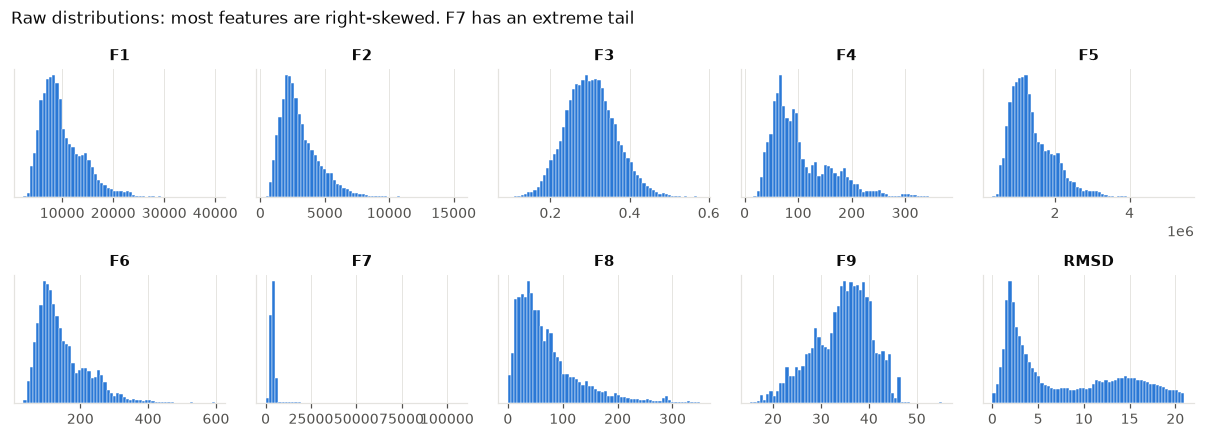

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4))
for ax, col in zip(axes.flat, FEATURES + [TARGET]):
    ax.hist(df[col], bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Raw distributions: most features are right-skewed. F7 has an extreme tail", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "raw_distributions", "eda")
plt.show()

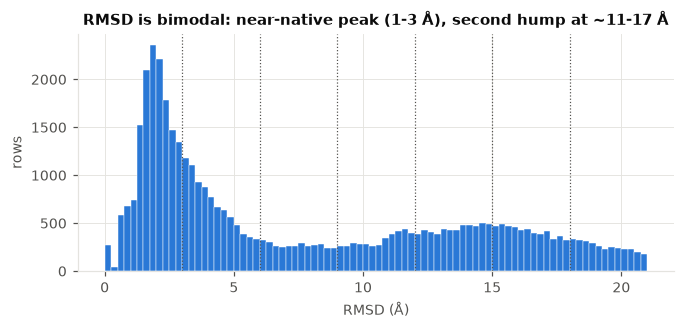

RMSD range: 0.00 to 21.00 Å, median 5.09 Å; rows with RMSD exactly 0: 272


In [5]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(df[TARGET], bins=np.arange(0, 21.25, 0.25), color=BLUE, edgecolor="white", linewidth=0.3)
for edge in RMSD_BIN_EDGES[1:-1]:
    ax.axvline(edge, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
ax.set_xlabel("RMSD (Å)")
ax.set_ylabel("rows")
ax.set_title("RMSD is bimodal: near-native peak (1-3 Å), second hump at ~11-17 Å")
plotting.save(fig, "rmsd_distribution", "eda")
plt.show()
print(f"RMSD range: {df[TARGET].min():.2f} to {df[TARGET].max():.2f} Å, median {df[TARGET].median():.2f} Å; "
      f"rows with RMSD exactly 0: {(df[TARGET] == 0).sum()}")

**Observations.** No missing values. All features are non-negative. F1, F2, F4, F5, F6 and F8
have skew > 1, and F7 (a Euclidean distance) has a very extreme right tail. F8 is integer-valued.
The target is bounded (0 to ~21 Å) and **bimodal**, not simply skewed. The dotted lines are the
3 Å bins used for stratification and per-bin evaluation.

### 1.2 Splitting

* **80 / 20 train/test hold-out, stratified on RMSD bin**, so the test set has the same target
  distribution (including the rarer 6-12 Å folds) as the training set. Fixed seed, so the test set
  is identical in every experiment and **locked** until final reporting.
* **5-fold stratified cross-validation on the training set** for every hyperparameter comparison
  (required by the spec). Inside each fold, a further 10 % of the fold's training part is held out
  for **early stopping**, so the stopping epoch is never chosen on the data we score.
* *Limitation:* the data has no protein IDs, so different decoys of the same protein can land in
  different splits. We cannot group by protein, so the scores may be slightly optimistic.

In [6]:
train_df, test_df = split_train_test(df)
print(f"train: {len(train_df)} rows | test: {len(test_df)} rows")

share = lambda d: pd.Series(np.bincount(rmsd_bin(d[TARGET]), minlength=7) / len(d), index=RMSD_BIN_LABELS)
(pd.DataFrame({"train %": share(train_df), "test %": share(test_df)}) * 100).round(2).T

train: 35215 rows | test: 8804 rows


,0-3,3-6,6-9,9-12,12-15,15-18,18-21
train %,34.34,18.80,7.48,8.87,12.14,11.34,7.03
test %,34.34,18.81,7.47,8.87,12.14,11.35,7.02


### 1.3 Feature relevance

Three complementary checks on the **training set**:
1. **Pearson / Spearman correlation** with RMSD: linear / monotonic relationships only.
2. **Mutual information (MI)**: any dependency, including non-linear. A column of pure random
   noise gives the "uninformative" reference value.
3. **Redundancy**: features that duplicate each other add no information.

In [7]:
from sklearn.feature_selection import mutual_info_regression

X_tr, y_tr = train_df[FEATURES], train_df[TARGET]
noise = pd.Series(np.random.default_rng(0).normal(size=len(X_tr)), name="NOISE (reference)")
X_with_noise = pd.concat([X_tr, noise], axis=1)

relevance = pd.DataFrame({
    "pearson": X_with_noise.corrwith(y_tr),
    "spearman": X_with_noise.corrwith(y_tr, method="spearman"),
    "mutual_info": mutual_info_regression(X_with_noise, y_tr, random_state=0),
})
relevance

,pearson,spearman,mutual_info
F1,-1.370e-02,-0.008,0.231
F2,1.587e-01,0.163,0.187
F3,3.750e-01,0.389,0.176
F4,-1.693e-01,-0.144,0.280
F5,-1.268e-02,-0.011,0.228
F6,-3.463e-02,-0.021,0.246
F7,-2.676e-03,-0.029,0.350
F8,-1.498e-04,0.073,0.243
F9,6.170e-02,0.061,0.297
NOISE (reference),1.292e-02,0.013,0.000


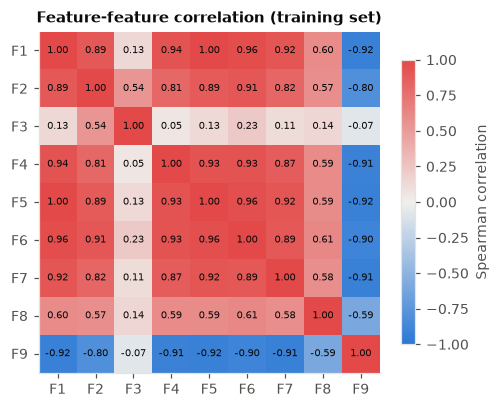

F5 / F1:        mean 138.5, coefficient of variation 0.026
F2 / (F1 × F3): mean 1.000, coefficient of variation 0.0000
MI(F5/F1 ratio, RMSD) = 0.089   vs noise 0.000


In [8]:
corr = X_tr.corr(method="spearman")
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr, cmap=plotting.DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.grid(False)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color=TEXT_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Feature-feature correlation (training set)")
plotting.save(fig, "feature_correlation", "eda")
plt.show()

# Two suspiciously strong relationships, checked directly:
ratio = X_tr["F5"] / X_tr["F1"]
print(f"F5 / F1:        mean {ratio.mean():.1f}, coefficient of variation {ratio.std() / ratio.mean():.3f}")
product = X_tr["F2"] / (X_tr["F1"] * X_tr["F3"])
print(f"F2 / (F1 × F3): mean {product.mean():.3f}, coefficient of variation {product.std() / product.mean():.4f}")

# F5 is not *exactly* proportional to F1. Does the small deviation (the ratio) carry information?
mi_ratio, mi_noise = mutual_info_regression(np.c_[ratio, noise], y_tr, random_state=0)
print(f"MI(F5/F1 ratio, RMSD) = {mi_ratio:.3f}   vs noise {mi_noise:.3f}")

**Model-based check.** Does removing a feature actually lose information? We fit a quick
gradient-boosted tree model (a strong non-linear model that needs no scaling, so it isolates the
*information content* of the features) with 5-fold CV on the training set, leaving out one feature
at a time.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

def cv_r2(columns):
    scores = []
    for fit_idx, val_idx in stratified_kfold(y_tr, k=5):
        model = HistGradientBoostingRegressor(random_state=0)
        model.fit(X_tr.iloc[fit_idx][columns], y_tr.iloc[fit_idx])
        scores.append(model.score(X_tr.iloc[val_idx][columns], y_tr.iloc[val_idx]))
    return np.mean(scores), np.std(scores)

base_mean, base_std = cv_r2(FEATURES)
rows = [{"left out": "(none)", "cv_r2": base_mean, "std": base_std, "change": 0.0}]
for f in FEATURES:
    m, s = cv_r2([c for c in FEATURES if c != f])
    rows.append({"left out": f, "cv_r2": m, "std": s, "change": m - base_mean})
m, s = cv_r2([c for c in FEATURES if c not in ("F2", "F5")])
rows.append({"left out": "F2 and F5 together", "cv_r2": m, "std": s, "change": m - base_mean})
drop_one = pd.DataFrame(rows).set_index("left out")
drop_one

,cv_r2,std,change
left out,,,
(none),0.546,0.009,0.000
F1,0.541,0.011,-0.005
F2,0.547,0.008,0.001
F3,0.540,0.010,-0.006
F4,0.491,0.007,-0.055
F5,0.543,0.011,-0.003
F6,0.525,0.011,-0.021
F7,0.529,0.009,-0.017
F8,0.493,0.007,-0.053


**Decision: keep 8 features, drop F2 as *redundant*.**
* **No feature is uninformative.** Every feature's MI is far above the noise reference (≈ 0), even
  though several have almost zero Pearson correlation. The relationships are non-linear, so a
  correlation filter alone would wrongly discard useful features. (This is also why an MLP suits
  this problem better than a linear model.)
* **F2 is computable from other features:** F2 = F1 × F3 exactly. F3 is the *fraction* of the
  exposed area that is non-polar, so non-polar exposed area (F2) = total area (F1) × F3. Leaving
  F2 out costs nothing (the change is within noise).
* **F5 looks like a copy of F1 but isn't quite one.** F5 (molecular-mass-weighted exposed area)
  ≈ 138.5 × F1, correlation 1.00, and the tree model barely notices its removal. But the ratio F5/F1
  (≈ the average mass of the exposed residues, i.e. composition rather than size) varies by ~2.6 %,
  and that ratio has clearly non-zero MI with RMSD. **Section 2.3 settles it with the MLP itself:**
  the MLP is consistently better with F5, so **F5 is kept**. (After `log1p`, log F5 − log F1 is
  exactly the log of the ratio, a simple *difference* that an MLP's first layer computes easily.)
* F4 and F6 are also highly correlated with F1 (ρ > 0.9) but are **not** functions of it. Removing
  them costs clearly more R² (F4 the most of all), so they are kept.

### 1.4 Outliers

Counting "outliers" with textbook rules on raw, skewed data mostly flags the *normal* right tail.
So we compare the counts before and after a `log1p` transform of the skewed features.

In [10]:
def outlier_counts(X):
    q1, q3 = X.quantile(0.25), X.quantile(0.75)
    iqr = q3 - q1
    z = (X - X.mean()) / X.std()
    return pd.DataFrame({
        "IQR rule (1.5)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).sum(),
        "|z| > 4": (z.abs() > 4).sum(),
    })

X_log = X_tr[INPUT_FEATURES].copy()
logged = [f for f in LOG_FEATURES if f in INPUT_FEATURES]
X_log[logged] = np.log1p(X_log[logged])
pd.concat({"raw": outlier_counts(X_tr[INPUT_FEATURES]), "after log1p": outlier_counts(X_log)}, axis=1)

raw            after log1p        
   IQR rule (1.5) |z| > 4 IQR rule (1.5) |z| > 4
F1            885      39             29       0
F3            295       7            295       7
F4            924      52              9       3
F5            821      38             19       0
F6            978      25             14       0
F7            411     150           1053     121
F8           1864     156            573       4
F9             95       0             95       0

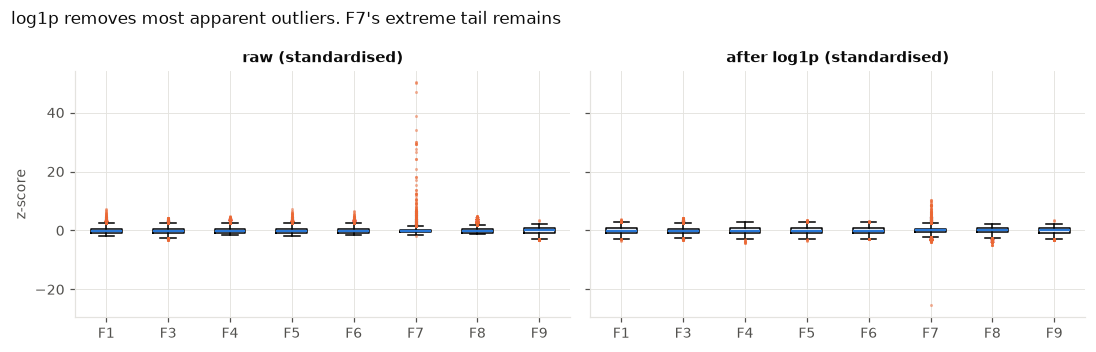

In [11]:
standardise = lambda X: (X - X.mean()) / X.std()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, X, title in [(axes[0], X_tr[INPUT_FEATURES], "raw (standardised)"),
                     (axes[1], X_log, "after log1p (standardised)")]:
    ax.boxplot(standardise(X).to_numpy(), tick_labels=INPUT_FEATURES, widths=0.5,
               flierprops=dict(marker=".", markersize=2, markeredgecolor=ORANGE, alpha=0.5),
               medianprops=dict(color=BLUE, linewidth=1.5))
    ax.set_title(title)
axes[0].set_ylabel("z-score")
fig.suptitle("log1p removes most apparent outliers. F7's extreme tail remains", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "outliers_before_after_log", "eda")
plt.show()

In [12]:
f7_extreme = X_tr["F7"] > X_tr["F7"].quantile(0.995)
print(f"F7 above its 99.5th percentile ({X_tr['F7'].quantile(0.995):.0f}): {f7_extreme.sum()} rows, "
      f"max {X_tr['F7'].max():.0f} vs median {X_tr['F7'].median():.0f}")
pd.DataFrame({
    "extreme-F7 rows": y_tr[f7_extreme].describe(),
    "all rows": y_tr.describe(),
}).T[["count", "mean", "25%", "50%", "75%"]]

F7 above its 99.5th percentile (11068): 177 rows, max 105948 vs median 3841


,count,mean,25%,50%,75%
extreme-F7 rows,177.0,8.657,3.174,5.951,13.857
all rows,35215.0,7.797,2.319,5.105,13.459


**Decision: transform and clip, don't delete.**
* Most "outliers" are the natural right tail of skewed, positive measurements (areas, masses).
  `log1p` makes them roughly symmetric, and the IQR flags for F1, F4, F6 and F8 drop sharply.
* **F7 is the exception.** Its raw maximum is ~28× its median, and even after the log it has extreme
  values (|z| > 4) at both ends. Its IQR count actually rises after the log, because the compressed
  bulk makes the low tail stand out. These rows look like
  measurement anomalies in F7 *only*: their other features and their RMSD values are ordinary and
  span the full range. Deleting them would throw away valid targets, and we could not delete such
  rows at prediction time anyway.
* So every feature is **clipped (winsorised) to its training-set 0.5th to 99.5th percentile** after
  the log. Rows are kept and extreme inputs can no longer dominate the weighted sums in the first
  layer.
* **The target is never treated as an outlier.** A large RMSD is a real bad fold, which is exactly
  what we are trying to predict.

### 1.5 Scaling

All features are continuous (F8 is an integer count but has 300+ distinct values), so they are
treated alike: `log1p` (skewed ones) → clip → **standardise** to mean 0, std 1. The target is
standardised for training and converted back to Å for every reported metric. All statistics come
from the training data (`Preprocessor.fit`).

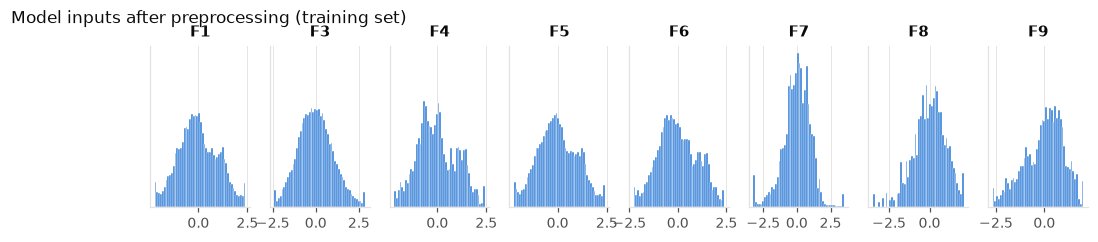

,F1,F3,F4,F5,F6,F7,F8,F9
mean,-6.500e-10,0.000,-1.300e-09,-1.300e-09,8.666e-10,0.000,2.167e-09,-6.500e-10
std,1.000e+00,1.000,1.000e+00,1.000e+00,1.000e+00,1.000,1.000e+00,1.000e+00
min,-2.227e+00,-2.399,-2.208e+00,-2.225e+00,-2.278e+00,-3.241,-3.489e+00,-2.668e+00
max,2.399e+00,2.863,2.425e+00,2.383e+00,2.389e+00,3.497,2.105e+00,2.016e+00


In [13]:
prep = Preprocessor().fit(train_df)
X_train = prep.transform_X(train_df)

fig, axes = plt.subplots(1, len(INPUT_FEATURES), figsize=(11, 1.9), sharey=True)
for i, (ax, col) in enumerate(zip(axes, INPUT_FEATURES)):
    ax.hist(X_train[:, i], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Model inputs after preprocessing (training set)", x=0.01, ha="left", y=1.05)
plotting.save(fig, "preprocessed_distributions", "eda")
plt.show()

pd.DataFrame({"mean": X_train.mean(axis=0), "std": X_train.std(axis=0),
              "min": X_train.min(axis=0), "max": X_train.max(axis=0)}, index=INPUT_FEATURES).T

**Why standardisation (and not min-max)?**
* Gradient descent works best when all inputs have a similar scale. Raw F5 is around 10⁶ while F3
  is around 0.3, so unscaled inputs would make the loss surface badly conditioned.
* Xavier/He initialisation assumes inputs with roughly unit variance.
* Sigmoid and tanh saturate (gradient ≈ 0) for large inputs. This matters for our activation axis.
* Min-max scaling would be distorted by F7's extreme values, squeezing the bulk of the data into a
  tiny interval. Log + clip + z-score avoids that.

### 1.6 Imbalance (skewed, bimodal target)

For regression, "imbalance" means some target ranges are much rarer than others.

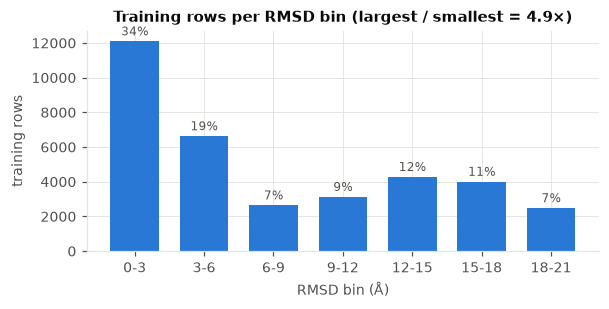

In [14]:
counts = pd.Series(np.bincount(rmsd_bin(y_tr), minlength=7), index=RMSD_BIN_LABELS)
fig, ax = plt.subplots(figsize=(6, 2.6))
bars = ax.bar(RMSD_BIN_LABELS, counts, color=BLUE, width=0.7)
ax.bar_label(bars, labels=[f"{c / counts.sum():.0%}" for c in counts], fontsize=8, color=TEXT_SECONDARY, padding=2)
ax.set_xlabel("RMSD bin (Å)")
ax.set_ylabel("training rows")
ax.set_title(f"Training rows per RMSD bin (largest / smallest = {counts.max() / counts.min():.1f}×)")
plotting.save(fig, "rmsd_bin_counts", "eda")
plt.show()

Why per-bin evaluation matters: a trivial model that always predicts the training mean, scored
on one CV fold (not the test set). Its overall RMSE looks like a single number, but its errors
are very different across bins.

In [15]:
fit_idx, val_idx = next(stratified_kfold(y_tr, k=5))
y_val = y_tr.iloc[val_idx].to_numpy()
y_pred_mean = np.full_like(y_val, y_tr.iloc[fit_idx].mean())

print("overall:", {k: round(v, 3) for k, v in regression_metrics(y_val, y_pred_mean).items()})
per_bin_metrics(y_val, y_pred_mean)

overall: {'rmse': 6.131, 'mae': 5.501, 'r2': -0.0}


,n,rmse,mae,bias
bin,,,,
0-3,2419,5.930,5.895,5.895
3-6,1324,3.694,3.596,3.596
6-9,526,0.907,0.765,0.294
9-12,625,2.981,2.855,-2.855
12-15,855,5.813,5.746,-5.746
15-18,799,8.672,8.630,-8.630
18-21,495,11.604,11.570,-11.570


**How imbalance is handled:**
* **Training:** stratified CV folds and early-stopping splits, so every fold sees the full RMSD
  range in the same proportions. We start with the plain (unweighted) MSE loss. In Phase 2 we
  compare it once against inverse-bin-frequency sample weights, and keep the weights only if they
  reduce the error in the rare bins without hurting the overall error much.
* **Testing:** the test set is stratified on the same bins.
* **Evaluation:** besides overall RMSE / MAE / R², we report **per-bin RMSE and bias**. Then good
  performance on the common 0-3 Å folds cannot hide poor performance on the rarer mid-range folds.
  The bias column shows *regression to the mean*: over-predicting low RMSD and under-predicting
  high RMSD.

### 1.7 Data preparation summary

| Step | Decision | Fitted on |
|---|---|---|
| Cleaning | Remove 1,711 exact duplicate rows → 44,019 rows | — |
| Splitting | 80/20 train/test, stratified on 3 Å RMSD bins, fixed seed. 5-fold stratified CV on train. 10 % of each fold's training part for early stopping | — |
| Feature relevance | Keep 8. Drop **F2** (= F1 × F3 exactly) as redundant. F5 kept: its ratio to F1 carries information (confirmed with the MLP, §2.3). No feature is uninformative (MI ≫ noise) | train |
| Outliers | `log1p` on skewed features, then clip to the 0.5th to 99.5th percentile. No rows deleted. Target untouched | train |
| Scaling | Standardise features (z-score). Standardise target for training, report in Å | train |
| Imbalance | Stratified splits, per-bin metrics. Loss weighting tested in Phase 2 | train |

## 2. The MLP, training loop and baseline

The mechanics, one file each (read them top to bottom; they are short):

| File | What it does |
|---|---|
| `src/model.py` | `MLP`: Linear → activation blocks, a linear output (regression), Xavier/He/random init |
| `src/schedules.py` | `learning_rate(step, ...)`: optional linear **warmup**, then constant or cosine |
| `src/training.py` | the explicit training loop: set LR → forward → MSE → backward → step; early stopping |
| `src/cv.py` | 5-fold CV: fit preprocessing on the fit rows, train, score the validation fold in Å |

Every configuration sees the **same folds**, so differences come from the configuration, not the split.

In [16]:
from dataclasses import replace
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

from src.cv import cross_validate, cross_validate_sklearn
from src.schedules import learning_rate
from src.training import TrainConfig
from src.utils import use_single_cpu_thread
from src.plotting import AQUA, YELLOW

use_single_cpu_thread()   # tiny networks train ~3.6x faster on one thread (see src/utils.py)
N_JOBS = 5                # run the 5 CV folds in parallel processes
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

BASELINE = TrainConfig()  # 2x64 ReLU, He init, Adam lr=1e-3, batch 256, early stopping (patience 20)
BASELINE

TrainConfig(hidden_sizes=(64, 64), activation='relu', init='auto', optimizer='adam', lr=0.001, batch_size=256, max_epochs=500, warmup_epochs=0.0, decay='constant', patience=20, weighted_loss=False, seed=0)

### 2.1 Learning-rate schedules

The LR is a plain function of the step (`src/schedules.py`) and is set before every optimiser step.
Part 3 uses the warmup variants. Illustrated over 100 epochs with 5 epochs of warmup.

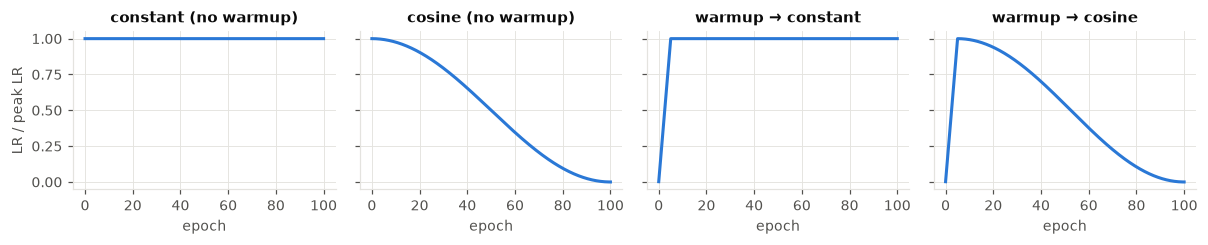

In [17]:
steps_per_epoch, epochs = 100, 100
total = steps_per_epoch * epochs
variants = [("constant (no warmup)", 0, "constant"), ("cosine (no warmup)", 0, "cosine"),
            ("warmup → constant", 5 * steps_per_epoch, "constant"), ("warmup → cosine", 5 * steps_per_epoch, "cosine")]

fig, axes = plt.subplots(1, 4, figsize=(11, 2.3), sharey=True)
for ax, (title, warmup, decay) in zip(axes, variants):
    lrs = [learning_rate(s, 1.0, total, warmup, decay) for s in range(total)]
    ax.plot(np.arange(total) / steps_per_epoch, lrs, color=BLUE)
    ax.set_title(title)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("LR / peak LR")
fig.tight_layout()
plotting.save(fig, "lr_schedules", "phase2")
plt.show()

### 2.2 Baseline: is the MLP learning anything useful?

**Hypothesis.** The MLP will clearly beat linear regression, because Phase 1 showed the
feature–RMSD relationships are mostly non-linear (high mutual information, near-zero Pearson r).
It should land close to a gradient-boosted tree model, a strong reference for tabular data.

To show the effect of the random seed, the MLP is cross-validated with 3 seeds (seed changes the
initial weights and mini-batch order, not the folds).

In [18]:
baselines = {
    "predict the mean": cross_validate_sklearn(DummyRegressor, train_df).summary(),
    "linear regression": cross_validate_sklearn(LinearRegression, train_df).summary(),
    "gradient boosting (reference)": cross_validate_sklearn(lambda: HistGradientBoostingRegressor(random_state=0), train_df).summary(),
}
mlp_runs = {seed: cross_validate(replace(BASELINE, seed=seed), train_df, n_jobs=N_JOBS) for seed in [0, 1, 2]}
for seed, res in mlp_runs.items():
    baselines[f"MLP 2x64 (seed {seed})"] = res.summary()

baseline_table = pd.DataFrame(baselines).T[["rmse_mean", "rmse_std", "mae_mean", "r2_mean", "r2_std", "best_epoch_mean"]]
baseline_table.to_csv(RESULTS / "phase2_baselines.csv")
baseline_table

,rmse_mean,rmse_std,mae_mean,r2_mean,r2_std,best_epoch_mean
predict the mean,6.136,0.005,5.515,-3.974e-06,3.718e-06,NaN
linear regression,5.185,0.045,4.247,2.860e-01,1.320e-02,NaN
gradient boosting (reference),4.134,0.044,3.123,5.462e-01,1.016e-02,NaN
MLP 2x64 (seed 0),4.094,0.046,3.027,5.548e-01,1.046e-02,149.4
MLP 2x64 (seed 1),4.095,0.029,3.012,5.547e-01,6.331e-03,140.8
MLP 2x64 (seed 2),4.080,0.046,3.002,5.578e-01,1.021e-02,171.8


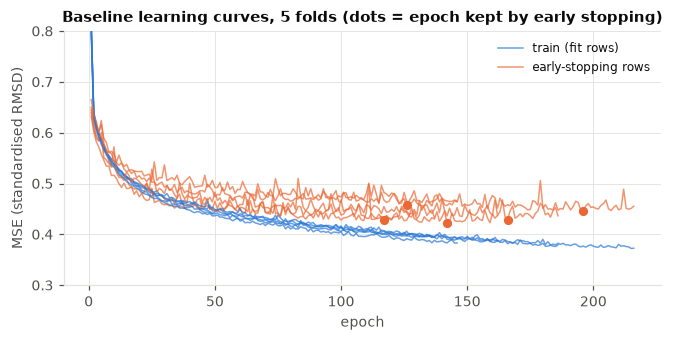

In [19]:
res = mlp_runs[0]
fig, ax = plt.subplots(figsize=(7, 3))
for fold, history in enumerate(res.histories):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], color=BLUE, linewidth=1, alpha=0.7, label="train (fit rows)" if fold == 0 else None)
    ax.plot(epochs, history["val_loss"], color=ORANGE, linewidth=1, alpha=0.7, label="early-stopping rows" if fold == 0 else None)
    best = res.folds.loc[fold, "best_epoch"]
    ax.plot(best, history["val_loss"][best - 1], "o", color=ORANGE, markersize=5)
ax.set_ylim(0.3, 0.8)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (standardised RMSD)")
ax.set_title("Baseline learning curves, 5 folds (dots = epoch kept by early stopping)")
ax.legend()
plotting.save(fig, "baseline_learning_curves", "phase2")
plt.show()

**Result: hypothesis supported.**
* The MLP reaches **RMSE ≈ 4.08–4.10 Å (R² ≈ 0.555)**, against 5.19 Å (R² 0.29) for linear regression and
  6.14 Å for predicting the mean. That's about 21 % lower error than linear regression, which confirms
  the relationships are non-linear. It is on par with (slightly better than) gradient boosting (4.13 Å).
* **Seed vs fold noise:** changing the seed moves the mean RMSE by only ~0.015 Å, while the
  fold-to-fold std is 0.03–0.05 Å. Differences smaller than this are not meaningful.
* **Learning curves:** the training loss keeps falling, but the early-stopping loss flattens after
  ~100 epochs and the gap widens. The network starts fitting details of its training rows that don't
  generalise (the onset of **overfitting**). Early stopping kept epochs 117–196. The early-stopping
  curve is jagged because the learning rate stays constant: with mini-batch noise the weights keep
  jittering around a minimum instead of settling. That is a motivation for LR decay, and is relevant
  to Section 4.
* **A ceiling:** two very different models (MLP and boosted trees) both stop at R² ≈ 0.55. That
  suggests the limit is the *information in the 8 features*, not the model.

### 2.3 Re-checking the feature decision with the MLP

Phase 1 judged redundancy with a tree model. Here the MLP itself decides: the same baseline is
cross-validated with 7, 8 and 9 inputs, over **5 seeds**. Because every run uses the same folds,
we compare each feature set with the 7-feature set *seed by seed* (a paired comparison). That
removes most of the seed-to-seed noise from the difference.

In [20]:
feature_sets = {
    "7: drop F2 and F5": [c for c in FEATURES if c not in ("F2", "F5")],
    "8: drop F5 only": [c for c in FEATURES if c != "F5"],
    "8: drop F2 only (chosen)": INPUT_FEATURES,
    "9: all features": FEATURES,
}
feature_rmse = pd.DataFrame({
    name: [cross_validate(replace(BASELINE, seed=seed), train_df, features=cols, n_jobs=N_JOBS).summary()["rmse_mean"]
           for seed in range(5)]
    for name, cols in feature_sets.items()
})
feature_rmse.index.name = "seed"
feature_rmse.to_csv(RESULTS / "phase2_feature_sets.csv")

paired = feature_rmse.sub(feature_rmse.iloc[:, 0], axis=0)   # difference vs the 7-feature set, per seed
pd.DataFrame({
    "cv_rmse_mean": feature_rmse.mean(),
    "std_over_seeds": feature_rmse.std(),
    "diff_vs_7_mean": paired.mean(),
    "seeds_better_than_7": (paired < 0).sum(),
})

,cv_rmse_mean,std_over_seeds,diff_vs_7_mean,seeds_better_than_7
7: drop F2 and F5,4.153,0.022,0.000,0
8: drop F5 only,4.160,0.019,0.007,3
8: drop F2 only (chosen),4.097,0.012,-0.056,5
9: all features,4.115,0.010,-0.037,4


**Result: the Phase 1 decision was half right.**
* **Dropping F2 is confirmed.** Adding F2 back (9 features) changes RMSE by +0.018 Å, which is
  within the seed-to-seed noise. F2 = F1 × F3 adds nothing.
* **Dropping F5 was wrong.** Without F5 (the 7- and "drop F5 only" sets) RMSE is ~0.06 Å worse, and
  the chosen 8-feature set beats the 7-feature set in **all 5 seeds** (paired). The effect is small
  (≈ 1.4 %) but consistent. So **F5 is kept**.
* **Why the tree model missed it:** F5 ≈ 138.5 × F1, but the ~2.6 % deviation (the ratio F5/F1 ≈
  average mass of the exposed residues) carries information (MI 0.089 vs 0.000 for noise). After
  `log1p` that ratio is a simple *difference*, log F5 − log F1, which an MLP's first layer computes
  with two weights. A tree splits on one feature at a time and needs many splits to approximate a
  difference of two features.
* **Lesson:** "redundant" depends on the model. Check feature decisions with the model you will
  actually use.

### 2.4 Imbalance: does loss weighting help?

**Hypothesis.** Weighting each training row by the inverse frequency of its RMSD bin will reduce the
error in the rare bins, at the cost of a higher overall error (the model stops minimising plain MSE).

Compared with 3 seeds. Per-bin errors use the out-of-fold predictions (every training row predicted
by the fold in which it was a validation row).

In [21]:
weighted_runs = {seed: cross_validate(replace(BASELINE, seed=seed, weighted_loss=True), train_df, n_jobs=N_JOBS)
                 for seed in [0, 1, 2]}
pd.DataFrame({
    "unweighted": pd.concat([mlp_runs[s].summary() for s in [0, 1, 2]], axis=1).mean(axis=1),
    "inverse-bin weighted": pd.concat([weighted_runs[s].summary() for s in [0, 1, 2]], axis=1).mean(axis=1),
}).T[["rmse_mean", "mae_mean", "r2_mean", "best_epoch_mean"]]

,rmse_mean,mae_mean,r2_mean,best_epoch_mean
unweighted,4.090,3.014,0.556,154.0
inverse-bin weighted,4.307,3.373,0.507,97.2


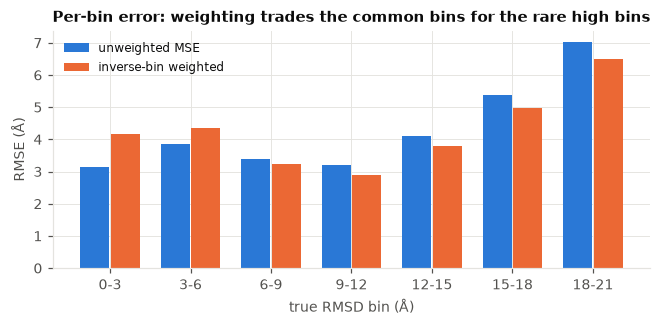

bin               0-3   3-6   6-9  9-12  12-15  15-18  18-21
unweighted rmse  3.14  3.85  3.39  3.21   4.10   5.39   7.02
           bias  1.90  2.21  1.31 -0.49  -2.34  -3.93  -5.62
weighted   rmse  4.16  4.36  3.24  2.91   3.80   4.97   6.48
           bias  2.85  2.81  1.43 -0.59  -2.40  -3.82  -5.38

In [22]:
def oof_per_bin(runs):
    """Per-bin RMSE and bias, averaged over seeds."""
    tables = [per_bin_metrics(r.predictions["y_true"], r.predictions["y_pred"]) for r in runs.values()]
    return pd.concat(tables).groupby(level=0, sort=False).mean()

bins_unweighted, bins_weighted = oof_per_bin(mlp_runs), oof_per_bin(weighted_runs)
per_bin_table = pd.concat({"unweighted": bins_unweighted[["rmse", "bias"]], "weighted": bins_weighted[["rmse", "bias"]]}, axis=1)
per_bin_table.to_csv(RESULTS / "phase2_loss_weighting_per_bin.csv")

x = np.arange(len(RMSD_BIN_LABELS))
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(x - 0.19, bins_unweighted["rmse"], width=0.36, color=BLUE, label="unweighted MSE")
ax.bar(x + 0.19, bins_weighted["rmse"], width=0.36, color=ORANGE, label="inverse-bin weighted")
ax.set_xticks(x, RMSD_BIN_LABELS)
ax.set_xlabel("true RMSD bin (Å)")
ax.set_ylabel("RMSE (Å)")
ax.set_title("Per-bin error: weighting trades the common bins for the rare high bins")
ax.legend()
plotting.save(fig, "loss_weighting_per_bin", "phase2")
plt.show()
per_bin_table.round(2).T

**Result: hypothesis partly supported. Decision: keep the unweighted MSE.**
* Weighting **does** lower the error in the five rarer bins (6–21 Å) by 0.15–0.54 Å, but it **raises**
  it in the two most common bins (0–3 Å: +1.02 Å, 3–6 Å: +0.51 Å), which hold 53 % of the rows.
  Overall RMSE gets worse (4.09 → 4.31 Å) and R² drops (0.556 → 0.507).
* **The bias is revealing.** Weighting barely changes the under-prediction of high RMSD (18–21 Å
  bias −5.6 → −5.4 Å). It mainly shifts *all* predictions upwards (0–3 Å bias +1.9 → +2.85 Å). So
  the high-bin errors are **not** mainly caused by the loss ignoring rare rows. The features don't
  separate high-RMSD decoys well, and the model hedges towards the middle (regression to the mean).
* Early stopping fires earlier with weights (97 vs 154 epochs): the model minimises a *weighted*
  loss while early stopping monitors the *unweighted* MSE, so the two disagree sooner.
* In practice (quality assessment) the near-native 0–3 Å decoys matter most, and weighting makes
  exactly those worse. The imbalance is therefore handled by stratified splits and per-bin reporting,
  not by loss weighting.

### 2.5 Baseline configuration (the reference for Section 3)

| Setting | Value | Why |
|---|---|---|
| Inputs | 8 features (F2 dropped) | §1.3 + §2.3 |
| Architecture | 2 hidden layers × 64 units, ReLU, He init | a common, modest starting point. Section 3 varies it |
| Optimiser | Adam, LR 1e-3, batch 256 | widely used defaults. Section 3 varies the optimiser |
| Loss | unweighted MSE on the standardised target | §2.4 |
| Stopping | early stopping on a 10 % split, patience 20, max 500 epochs | keeps the best epoch without overfitting |